In [11]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [12]:
class AgentState(TypedDict):
    number1: int
    number2: int
    number3: int
    number4: int
    operations1: str
    operations2: str
    result1: int
    result2: int

In [13]:
def adder1(state: AgentState):
    """This node add 2 number"""
    state['result1'] = state["number1"] + state["number2"]
    return state


def adder2(state: AgentState):
    """This node add 2 number"""
    state['result2'] = state["number3"] + state["number4"]
    return state


def subtract1(state: AgentState):
    """This node subtract two number"""
    state["result1"] = state["number1"] - state["number2"]
    return state


def subtract2(state: AgentState):
    """This node subtract two number"""
    state["result2"] = state["number3"] - state["number4"]
    return state


def decode_next_node1(state: AgentState) -> str:
    """"This node will select the next node of the graph"""
    if state["operations1"] == "+":
        return "add1"
    elif state["operations1"] == "-":
        return "subtract1"
    return ""


def decode_next_node2(state: AgentState) -> str:
    """"This node will select the next node of the graph"""
    if state["operations2"] == "+":
        return "add2"
    elif state["operations2"] == "-":
        return "subtract2"
    return ""

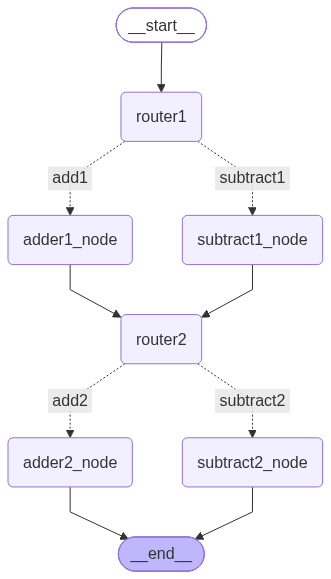

In [14]:
graph = StateGraph(AgentState)
graph.add_node("adder1_node", adder1)
graph.add_node("subtract1_node", subtract1)
graph.add_node("adder2_node", adder2)
graph.add_node("subtract2_node", subtract2)
graph.add_node("router1", lambda state: state)
graph.add_node("router2", lambda state: state)

graph.add_edge(START, "router1")
graph.add_conditional_edges(
    'router1', decode_next_node1,
    {
        "add1": "adder1_node",
        "subtract1": "subtract1_node"
    }
)
graph.add_edge("adder1_node", "router2")
graph.add_edge("subtract1_node", "router2")

graph.add_conditional_edges(
    "router2", decode_next_node2,
    {
        "add2": "adder2_node",
        "subtract2": "subtract2_node"
    }
)

graph.add_edge("adder2_node", END)
graph.add_edge("subtract2_node", END)

bot = graph.compile()
bot

In [15]:
input_state = {
    "number1": 200,
    "number2": 100,
    "number3": 200,
    "number4": 100,
    "operations1": "+",
    "operations2": "-"
}

response = bot.invoke(input_state)
response

{'number1': 200,
 'number2': 100,
 'number3': 200,
 'number4': 100,
 'operations1': '+',
 'operations2': '-',
 'result1': 300,
 'result2': 100}